# IPL Bowler Economy Prediction

Simple practical analysis: use IPL match data to predict bowling economy from the target score given by the user.

One-line explanation: I use target score as input and predict the expected bowler economy with a simple regression model.

In [5]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\stg3001\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load IPL data
deliveries_df = pd.read_csv('../datasets/deliveries.csv')
matches_df = pd.read_csv('../datasets/matches.csv')

# Add season information to each delivery
merged_df = deliveries_df.merge(matches_df[['id', 'season']], left_on='match_id', right_on='id', how='left')
merged_df['is_legal_delivery'] = ~merged_df['extras_type'].isin(['wides', 'noballs'])

# Quick preview of merged data
display(merged_df.head())

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season,is_legal_delivery
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08,True
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08,True
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08,False
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08,True
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08,True


Step 1 : Season Averages

In [8]:
# Season average runs per match
season_match_runs = merged_df.groupby(['season', 'match_id'], as_index=False)['total_runs'].sum()
print(season_match_runs.head(2))

season_runs = season_match_runs.groupby('season', as_index=False)['total_runs'].mean().rename(columns={'total_runs': 'avg_runs_per_match'})
print(season_runs.head(2))

# Season average bowler economy
season_bowler = merged_df.groupby(['season', 'bowler'], as_index=False).agg(
    runs_conceded=('total_runs', 'sum'),
    legal_balls=('is_legal_delivery', 'sum')
)
season_bowler['overs_bowled'] = season_bowler['legal_balls'] / 6

season_bowler = season_bowler[season_bowler['overs_bowled'] >= 20].copy()
season_bowler['economy_rate'] = season_bowler['runs_conceded'] / season_bowler['overs_bowled']
season_economy = season_bowler.groupby('season', as_index=False)['economy_rate'].mean().rename(columns={'economy_rate': 'avg_economy'})

# Season summary table
season_summary = season_runs.merge(season_economy, on='season', how='inner').sort_values('season')
display(season_summary)

    season  match_id  total_runs
0  2007/08    335982         304
1  2007/08    335983         447
    season  avg_runs_per_match
0  2007/08          309.258621
1     2009          286.894737


,season,avg_runs_per_match,avg_economy
0,2007/08,309.258621,8.183018
1,2009,286.894737,7.380867
2,2009/10,314.716667,7.877345
3,2011,289.780822,7.524107
4,2012,303.418919,7.643143
5,2013,297.394737,7.579296
6,2014,315.516667,8.141255
7,2015,311.067797,8.136126
8,2016,314.366667,8.212233
9,2017,318.406780,8.261886


Step 2 : Individual Bowler Classification

In [9]:
# Bowler economy for each season
bowler_season = merged_df.groupby(['season', 'bowler'], as_index=False).agg(
    runs_conceded=('total_runs', 'sum'),
    legal_balls=('is_legal_delivery', 'sum')
)
bowler_season['overs_bowled'] = bowler_season['legal_balls'] / 6
bowler_season = bowler_season[bowler_season['overs_bowled'] >= 20].copy()
bowler_season['economy_rate'] = bowler_season['runs_conceded'] / bowler_season['overs_bowled']

# Compare each bowler with the average economy for that season
bowler_classification = bowler_season.merge(
    season_summary[['season', 'avg_economy']],
    on='season',
    how='left'
)
bowler_classification['economical_status'] = np.where(
    bowler_classification['economy_rate'] < bowler_classification['avg_economy'],
    'Economical',
    'Not economical'
)

most_economical_bowler = bowler_classification.sort_values(by="economy_rate", ascending=True).head(1)

print("Bowler:", most_economical_bowler["bowler"].iloc[0])
print("Economy:", most_economical_bowler["economy_rate"].iloc[0])

display(bowler_classification.head(20))

Bowler: M Muralitharan
Economy: 5.34


,season,bowler,runs_conceded,legal_balls,overs_bowled,economy_rate,avg_economy,economical_status
0,2007/08,A Kumble,314,230,38.333333,8.191304,8.183018,Not economical
1,2007/08,A Nehra,357,269,44.833333,7.962825,8.183018,Economical
2,2007/08,AB Agarkar,211,156,26.000000,8.115385,8.183018,Economical
3,2007/08,AB Dinda,266,234,39.000000,6.820513,8.183018,Economical
4,2007/08,CRD Fernando,164,120,20.000000,8.200000,8.183018,Not economical
5,2007/08,DJ Bravo,239,171,28.500000,8.385965,8.183018,Not economical
6,2007/08,DP Vijaykumar,205,152,25.333333,8.092105,8.183018,Economical
7,2007/08,DS Kulkarni,242,177,29.500000,8.203390,8.183018,Not economical
8,2007/08,DW Steyn,265,228,38.000000,6.973684,8.183018,Economical
9,2007/08,GD McGrath,366,324,54.000000,6.777778,8.183018,Economical


Step 3 : Simple Results

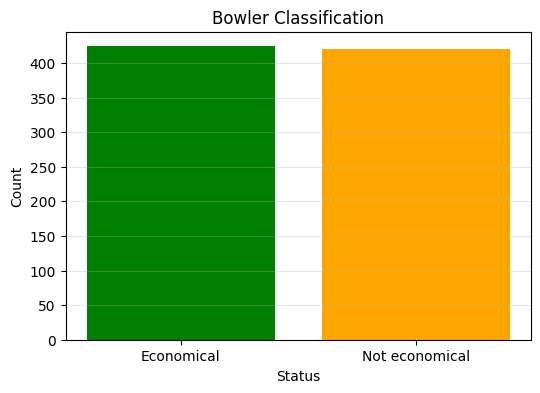

Economical bowlers:


,season,bowler,overs_bowled,economy_rate,avg_economy
1,2007/08,A Nehra,44.833333,7.962825,8.183018
2,2007/08,AB Agarkar,26.000000,8.115385,8.183018
3,2007/08,AB Dinda,39.000000,6.820513,8.183018
6,2007/08,DP Vijaykumar,25.333333,8.092105,8.183018
8,2007/08,DW Steyn,38.000000,6.973684,8.183018
9,2007/08,GD McGrath,54.000000,6.777778,8.183018
11,2007/08,IK Pathan,53.000000,6.811321,8.183018
17,2007/08,M Muralitharan,58.000000,7.172414,8.183018
18,2007/08,M Ntini,35.000000,7.342857,8.183018
19,2007/08,MF Maharoof,36.000000,7.083333,8.183018


Not economical bowlers:


,season,bowler,overs_bowled,economy_rate,avg_economy
0,2007/08,A Kumble,38.333333,8.191304,8.183018
4,2007/08,CRD Fernando,20.000000,8.200000,8.183018
5,2007/08,DJ Bravo,28.500000,8.385965,8.183018
7,2007/08,DS Kulkarni,29.500000,8.203390,8.183018
10,2007/08,I Sharma,42.166667,8.252964,8.183018
12,2007/08,JA Morkel,48.000000,8.625000,8.183018
13,2007/08,JH Kallis,34.333333,9.378641,8.183018
14,2007/08,JR Hopes,28.000000,10.178571,8.183018
15,2007/08,Joginder Sharma,24.666667,9.770270,8.183018
16,2007/08,L Balaji,33.000000,8.878788,8.183018


In [10]:
# Count of economical vs not economical bowlers
status_counts = bowler_classification['economical_status'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values, color=['green', 'orange'])
plt.title('Bowler Classification')
plt.xlabel('Status')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Show examples
print('Economical bowlers:')
display(bowler_classification[bowler_classification['economical_status'] == 'Economical'][['season', 'bowler', 'overs_bowled', 'economy_rate', 'avg_economy']].head(15))

print('Not economical bowlers:')
display(bowler_classification[bowler_classification['economical_status'] == 'Not economical'][['season', 'bowler', 'overs_bowled', 'economy_rate', 'avg_economy']].head(15))

## Step 4 : Build Bowler-Level Training Data

Create one row per bowler per match, keep only bowlers with at least 20 overs overall, and use `target_runs` plus bowler name for prediction.

In [18]:
merged_prediction_df = deliveries_df.merge(
    matches_df[['id', 'target_runs', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)

merged_prediction_df['is_legal_delivery'] = ~merged_prediction_df['extras_type'].isin(['wides', 'noballs'])

bowler_match_df = merged_prediction_df.groupby(
    ['match_id', 'season', 'target_runs', 'bowler'],
    as_index=False
).agg(
    runs_conceded=('total_runs', 'sum'),
    legal_balls=('is_legal_delivery', 'sum')
)

bowler_match_df['overs_bowled'] = bowler_match_df['legal_balls'] / 6
bowler_match_df = bowler_match_df[bowler_match_df['overs_bowled'] > 0].copy()
bowler_match_df['economy_rate'] = bowler_match_df['runs_conceded'] / bowler_match_df['overs_bowled']

bowler_overall_overs = bowler_match_df.groupby('bowler', as_index=False)['overs_bowled'].sum()
experienced_bowlers = bowler_overall_overs[bowler_overall_overs['overs_bowled'] >= 20]['bowler']
bowler_match_df = bowler_match_df[bowler_match_df['bowler'].isin(experienced_bowlers)].copy()

print('Training rows:', len(bowler_match_df))
display(bowler_match_df[['match_id', 'season', 'bowler', 'target_runs', 'economy_rate']].head())

Training rows: 12296


,match_id,season,bowler,target_runs,economy_rate
1,335982,2007/08,AB Agarkar,223.0,6.250000
2,335982,2007/08,AB Dinda,223.0,3.000000
4,335982,2007/08,I Sharma,223.0,4.333333
5,335982,2007/08,JH Kallis,223.0,13.000000
6,335982,2007/08,LR Shukla,223.0,10.285714


## Step 5 : Train a Bowler Economy Model

Fit a simple regression model with target score and bowler identity so the notebook can predict an individual bowler's economy.

Mean absolute error: 2.2671
R2 score: 0.1163


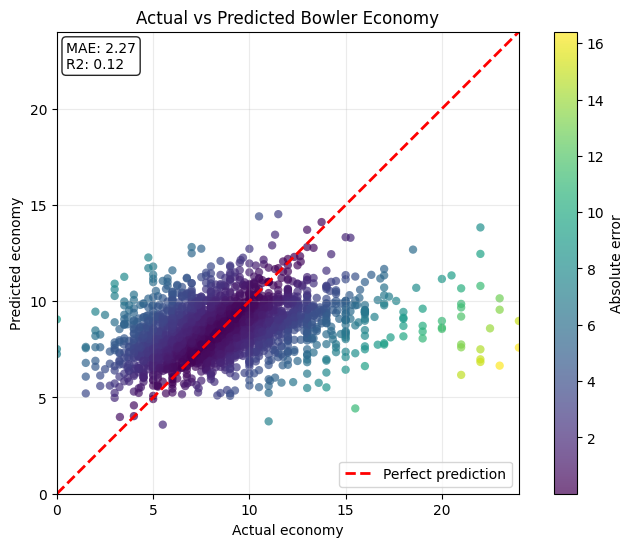

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = bowler_match_df[['target_runs', 'bowler']]
y = bowler_match_df['economy_rate']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('bowler', OneHotEncoder(handle_unknown='ignore'), ['bowler'])
    ],
    remainder='passthrough'
)

bowler_economy_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

bowler_economy_model.fit(X_train, y_train)

predictions = bowler_economy_model.predict(X_test)
abs_errors = np.abs(y_test - predictions)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Mean absolute error:', round(mae, 4))
print('R2 score:', round(r2, 4))

plot_min = min(y_test.min(), predictions.min())
plot_max = max(y_test.max(), predictions.max())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    y_test,
    predictions,
    c=abs_errors,
    cmap='viridis',
    alpha=0.7,
    edgecolors='none'
)
plt.plot([plot_min, plot_max], [plot_min, plot_max], color='red', linestyle='--', linewidth=2, label='Perfect prediction')
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar(scatter, label='Absolute error')
plt.xlabel('Actual economy')
plt.ylabel('Predicted economy')
plt.title('Actual vs Predicted Bowler Economy')
plt.grid(alpha=0.25)
plt.legend()
plt.text(
    0.02,
    0.98,
    f'MAE: {mae:.2f}\nR2: {r2:.2f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)
plt.show()

## Step 6 : Predict Bowler Economy from User Input

Enter the target score and bowler name to get the predicted economy, then see the top 10 economical bowlers for that score.

In [24]:
target_score = float(input('Enter target score: '))
bowler_name = input('Enter bowler name: ').strip()

if bowler_name in experienced_bowlers.values:
    bowler_input = pd.DataFrame({'target_runs': [target_score], 'bowler': [bowler_name]})
    predicted_economy = bowler_economy_model.predict(bowler_input)[0]
    print(f'Predicted economy for {bowler_name} at target score {target_score}: {predicted_economy:.2f}')
else:
    print(f'{bowler_name} is not eligible because the model only uses bowlers with at least 20 overs.')

score_input_df = pd.DataFrame({
    'target_runs': [target_score] * len(experienced_bowlers),
    'bowler': experienced_bowlers.tolist()
})
score_predictions = bowler_economy_model.predict(score_input_df)

score_prediction_df = pd.DataFrame({
    'bowler': score_input_df['bowler'],
    'predicted_economy': score_predictions
}).sort_values('predicted_economy', ascending=True)

print('\nTop 10 economical bowlers for this target score:')
display(score_prediction_df.head(10))

Predicted economy for I Sharma at target score 100.0: 6.67

Top 10 economical bowlers for this target score:


,bowler,predicted_economy
85,FH Edwards,4.399485
271,SS Cottrell,4.583818
90,GD McGrath,4.707199
269,SP Narine,4.957377
63,CK Langeveldt,5.013707
175,MJ Santner,5.031909
240,Rashid Khan,5.072722
281,Sohail Tanvir,5.075493
164,M Muralitharan,5.101050
77,DL Vettori,5.137280
